In [1]:
# ============================================================
# CELL 1 — IMPORTS + CONFIGURATION
# ============================================================

from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import os
import json
import math
import time
import colorsys
import warnings

import requests
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation
)

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering
)

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import PCA

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.model_selection import (
    train_test_split
)

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)


warnings.filterwarnings(
    "ignore"
)


# ============================================================
# PROJECT
# ============================================================

PROJECT_DIR = (
    Path.home()
    / "OneDrive"
    / "Desktop"
    / "family-toilet-search"
)

DATA_DIR = (
    PROJECT_DIR
    / "data"
)

GENERATED_DIR = (
    DATA_DIR
    / "generated"
)

ROUTE_LIBRARY_PATH = (
    GENERATED_DIR
    / "residential_route_library.json"
)


# ============================================================
# GENERATED OUTPUT FOLDERS
# ============================================================

STREET_IMAGE_DIR = (
    GENERATED_DIR
    / "street_images"
)

SEGMENTATION_DIR = (
    GENERATED_DIR
    / "segmentation_images"
)

SEMANTIC_FEATURE_DIR = (
    GENERATED_DIR
    / "semantic_features"
)

ML_DIR = (
    GENERATED_DIR
    / "ml_analysis"
)

VISUAL_DIR = (
    ML_DIR
    / "visuals"
)


for folder in [
    STREET_IMAGE_DIR,
    SEGMENTATION_DIR,
    SEMANTIC_FEATURE_DIR,
    ML_DIR,
    VISUAL_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# OUTPUT FILES
# ============================================================

CHECKPOINT_DATA_PATH = (
    ML_DIR
    / "checkpoint_environmental_analysis.csv"
)

CLUSTER_SUMMARY_PATH = (
    ML_DIR
    / "cluster_summary.json"
)

PCA_LOADINGS_PATH = (
    ML_DIR
    / "pca_loadings.csv"
)

TRAINING_LABEL_PATH = (
    ML_DIR
    / "support_need_training_labels.csv"
)

GRASSHOPPER_PATH = (
    GENERATED_DIR
    / "grasshopper_route_features.csv"
)

WEBSITE_ANALYSIS_PATH = (
    GENERATED_DIR
    / "family_route_analysis.json"
)


# ============================================================
# MODEL
# ============================================================

MODEL_NAME = (
    "nvidia/segformer-b2-finetuned-ade-512-512"
)

MODEL_VERSION = (
    "segformer-b2-ade512-family-v2"
)


DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else
    "cpu"
)


# ============================================================
# IMAGE ANALYSIS SETTINGS
# ============================================================

MAX_IMAGES_PER_CHECKPOINT = 1

K_CANDIDATES = [
    3,
    4,
    5,
    6
]

RANDOM_STATE = 42


HTTP = requests.Session()

HTTP.headers.update({
    "User-Agent":
        "young-family-route-research/2.0"
})


print(
    "Device:",
    DEVICE
)

print(
    "Project:",
    PROJECT_DIR
)

print(
    "Route library:",
    ROUTE_LIBRARY_PATH
)


C:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Project: C:\Users\MSI\OneDrive\Desktop\family-toilet-search
Route library: C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\residential_route_library.json


In [2]:
# ============================================================
# CELL 2 — LOAD ROUTE LIBRARY
# ============================================================

if not ROUTE_LIBRARY_PATH.exists():

    raise FileNotFoundError(
        "residential_route_library.json does not exist.\n"
        "Finish route_imagery_backend.ipynb first."
    )


with open(
    ROUTE_LIBRARY_PATH,
    "r",
    encoding="utf-8"
) as f:

    ROUTE_LIBRARY = (
        json.load(f)
    )


ROUTES_BY_ID = (
    ROUTE_LIBRARY.get(
        "routesById",
        {}
    )
)


if not ROUTES_BY_ID:

    raise RuntimeError(
        "No routes found in route library."
    )


route_count = (
    len(
        ROUTES_BY_ID
    )
)


checkpoint_count = sum(

    len(
        route.get(
            "checkpoints",
            []
        )
    )

    for route in
    ROUTES_BY_ID.values()
)


image_reference_count = sum(

    len(
        checkpoint.get(
            "imageCandidates",
            []
        )
    )

    for route in
    ROUTES_BY_ID.values()

    for checkpoint in
    route.get(
        "checkpoints",
        []
    )
)


routes_with_recorded_support = sum(

    1

    for route in
    ROUTES_BY_ID.values()

    if route.get(
        "recordedSupportIds"
    )
)


print(
    "Routes:",
    route_count
)

print(
    "Checkpoints:",
    checkpoint_count
)

print(
    "Image references:",
    image_reference_count
)

print(
    "Routes with recorded support:",
    routes_with_recorded_support
)

Routes: 120
Checkpoints: 2685
Image references: 3962
Routes with recorded support: 26


In [3]:
# ============================================================
# CELL 3 — LOAD SEGFORMER
# ============================================================

print(
    "Loading:",
    MODEL_NAME
)


processor = (
    SegformerImageProcessor
    .from_pretrained(
        MODEL_NAME
    )
)


model = (
    SegformerForSemanticSegmentation
    .from_pretrained(
        MODEL_NAME
    )
    .to(
        DEVICE
    )
)


model.eval()


ID_TO_LABEL = {

    int(key):
        str(value).lower()

    for key, value in
    model.config.id2label.items()
}


print(
    "Semantic classes:",
    len(
        ID_TO_LABEL
    )
)

print(
    "Model ready."
)

Loading: nvidia/segformer-b2-finetuned-ade-512-512


Loading weights: 100%|██████████| 380/380 [00:00<00:00, 6993.27it/s]

Semantic classes: 150
Model ready.


In [4]:
# ============================================================
# CELL 4 — ENVIRONMENTAL FEATURE GROUPS
# ============================================================

FEATURE_GROUPS = {

    # How open / exposed the scene is
    "sky_exposure": [
        "sky"
    ],

    # Vegetative presence
    "greenery": [
        "tree",
        "grass",
        "plant",
        "flower",
        "palm"
    ],

    # Vehicular surface
    "road_exposure": [
        "road",
        "street"
    ],

    # Space associated with walking
    "pedestrian_space": [
        "sidewalk",
        "pavement",
        "path",
        "stair",
        "stairs"
    ],

    # Built enclosure / frontage
    "built_frontage": [
        "building",
        "wall",
        "house",
        "skyscraper"
    ],

    # Vehicles visible
    "vehicle_presence": [
        "car",
        "truck",
        "bus",
        "van",
        "motorbike",
        "motorcycle",
        "bicycle"
    ],

    # Human activity
    "human_presence": [
        "person"
    ],

    # Visual evidence only.
    # We do NOT assume ADE20K definitely contains all of these.
    "visual_rest_support": [
        "bench",
        "chair",
        "seat",
        "sofa"
    ]
}


def ids_matching_keywords(
    keywords
):

    matches = set()


    for class_id, label in (
        ID_TO_LABEL.items()
    ):

        for keyword in keywords:

            if (
                keyword.lower()
                in
                label.lower()
            ):

                matches.add(
                    class_id
                )


    return matches


FEATURE_CLASS_IDS = {

    feature:
        ids_matching_keywords(
            keywords
        )

    for feature, keywords in
    FEATURE_GROUPS.items()
}


print(
    "SEGFORMER FEATURE MAPPING"
)

print(
    "=============================================="
)


for feature, class_ids in (
    FEATURE_CLASS_IDS.items()
):

    labels = [
        ID_TO_LABEL[
            class_id
        ]

        for class_id in
        sorted(
            class_ids
        )
    ]


    print(
        feature,
        "→",
        labels
    )

SEGFORMER FEATURE MAPPING
sky_exposure → ['sky', 'skyscraper']
greenery → ['tree', 'grass', 'plant', 'flower', 'palm', 'streetlight']
road_exposure → ['road', 'streetlight']
pedestrian_space → ['sidewalk', 'path', 'stairs', 'stairway']
built_frontage → ['wall', 'building', 'house', 'skyscraper']
vehicle_presence → ['car', 'bus', 'truck', 'van', 'bicycle']
human_presence → ['person']
visual_rest_support → ['chair', 'sofa', 'armchair', 'seat', 'bench', 'swivel chair']


In [5]:
# ============================================================
# CELL 5 — COLOUR PALETTE
# ============================================================

def build_palette(
    count
):

    palette = []


    for index in range(
        count
    ):

        hue = (
            index
            /
            max(
                count,
                1
            )
        )


        r, g, b = (
            colorsys.hsv_to_rgb(
                hue,
                0.72,
                0.84
            )
        )


        palette.append(
            (
                int(
                    r * 255
                ),
                int(
                    g * 255
                ),
                int(
                    b * 255
                )
            )
        )


    return palette


SEGMENTATION_PALETTE = (
    build_palette(
        max(
            ID_TO_LABEL.keys()
        )
        +
        1
    )
)


def segmentation_to_image(
    segmentation
):

    height, width = (
        segmentation.shape
    )


    output = np.zeros(
        (
            height,
            width,
            3
        ),
        dtype=np.uint8
    )


    for class_id in (
        np.unique(
            segmentation
        )
    ):

        class_id = (
            int(
                class_id
            )
        )


        if (
            class_id
            <
            len(
                SEGMENTATION_PALETTE
            )
        ):

            output[
                segmentation
                ==
                class_id
            ] = (
                SEGMENTATION_PALETTE[
                    class_id
                ]
            )


    return Image.fromarray(
        output
    )


print(
    "Segmentation palette ready."
)

Segmentation palette ready.


In [6]:
# ============================================================
# CELL 6 — IMAGE CACHE
# ============================================================

def safe_filename(
    value
):

    return (
        str(value)
        .replace(
            "/",
            "_"
        )
        .replace(
            "\\",
            "_"
        )
        .replace(
            ":",
            "_"
        )
    )


def local_image_path(
    image_id
):

    return (
        STREET_IMAGE_DIR
        /
        (
            safe_filename(
                image_id
            )
            +
            ".jpg"
        )
    )


def local_segmentation_path(
    image_id
):

    return (
        SEGMENTATION_DIR
        /
        (
            safe_filename(
                image_id
            )
            +
            ".png"
        )
    )


def local_feature_path(
    image_id
):

    return (
        SEMANTIC_FEATURE_DIR
        /
        (
            safe_filename(
                image_id
            )
            +
            "_"
            +
            MODEL_VERSION
            +
            ".json"
        )
    )


def download_image(
    image_id,
    url
):

    path = (
        local_image_path(
            image_id
        )
    )


    if (
        path.exists()
        and
        path.stat().st_size
        >
        0
    ):

        return path


    if not url:

        return None


    try:

        response = (
            HTTP.get(
                url,
                timeout=30
            )
        )


        response.raise_for_status()


        path.write_bytes(
            response.content
        )


        return path


    except Exception as error:

        print(
            "Download failed:",
            image_id,
            str(
                error
            )[:100]
        )


        return None


print(
    "Image cache ready."
)

Image cache ready.


In [7]:
# ============================================================
# CELL 7 — SEGMENTATION ANALYSIS
# ============================================================

def calculate_semantic_features(
    segmentation
):

    total_pixels = float(
        segmentation.size
    )


    output = {}


    for feature_name, class_ids in (
        FEATURE_CLASS_IDS.items()
    ):

        if not class_ids:

            output[
                feature_name
            ] = 0.0

            continue


        mask = (
            np.isin(
                segmentation,
                list(
                    class_ids
                )
            )
        )


        output[
            feature_name
        ] = (
            float(
                mask.sum()
            )
            /
            total_pixels
        )


    return output


def analyse_image(
    image_id,
    image_url
):

    feature_path = (
        local_feature_path(
            image_id
        )
    )


    segmentation_path = (
        local_segmentation_path(
            image_id
        )
    )


    # ========================================================
    # CACHE
    # ========================================================

    if (
        feature_path.exists()
        and
        segmentation_path.exists()
    ):

        with open(
            feature_path,
            "r",
            encoding="utf-8"
        ) as f:

            return json.load(
                f
            )


    # ========================================================
    # IMAGE
    # ========================================================

    image_path = (
        download_image(
            image_id,
            image_url
        )
    )


    if image_path is None:

        return None


    try:

        image = (
            Image.open(
                image_path
            )
            .convert(
                "RGB"
            )
        )


    except Exception:

        return None


    # ========================================================
    # MODEL INFERENCE
    # ========================================================

    inputs = (
        processor(
            images=image,
            return_tensors="pt"
        )
    )


    inputs = {

        key:
            value.to(
                DEVICE
            )

        for key, value in
        inputs.items()
    }


    with torch.no_grad():

        outputs = (
            model(
                **inputs
            )
        )


    logits = (
        outputs.logits
    )


    upsampled = (
        F.interpolate(
            logits,
            size=(
                image.height,
                image.width
            ),
            mode="bilinear",
            align_corners=False
        )
    )


    segmentation = (
        upsampled
        .argmax(
            dim=1
        )[0]
        .cpu()
        .numpy()
        .astype(
            np.int16
        )
    )


    features = (
        calculate_semantic_features(
            segmentation
        )
    )


    # ========================================================
    # SAVE COLOURED SEGMENTATION
    # ========================================================

    colour_image = (
        segmentation_to_image(
            segmentation
        )
    )


    colour_image.save(
        segmentation_path
    )


    record = {

        "imageId":
            str(
                image_id
            ),

        "originalImage":
            (
                "./data/generated/street_images/"
                +
                image_path.name
            ),

        "segmentationImage":
            (
                "./data/generated/segmentation_images/"
                +
                segmentation_path.name
            ),

        "features":
            features,

        "model":
            MODEL_NAME,

        "modelVersion":
            MODEL_VERSION
    }


    with open(
        feature_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            record,
            f,
            indent=2
        )


    return record


print(
    "SegFormer analysis function ready."
)

SegFormer analysis function ready.


In [8]:
# ============================================================
# CELL 8 — CHECKPOINT OBSERVATIONS
# ============================================================

observations = []


for route_id, route in (
    ROUTES_BY_ID.items()
):

    route_distance = float(
        route.get(
            "distance_m",
            0
        )
    )


    route_support_ids = (
        route.get(
            "recordedSupportIds",
            []
        )
    )


    route_has_support = (
        len(
            route_support_ids
        )
        >
        0
    )


    route_has_pcn = bool(
        route.get(
            "mobilityCorridorIds",
            []
        )
    )


    for checkpoint in (
        route.get(
            "checkpoints",
            []
        )
    ):

        candidates = (
            checkpoint.get(
                "imageCandidates",
                []
            )
        )


        if not candidates:

            continue


        candidates = sorted(

            candidates,

            key=lambda item:
                item.get(
                    "distance_m",
                    999999
                )
        )


        image = (
            candidates[0]
        )


        image_id = (
            image.get(
                "id"
            )
        )


        if not image_id:

            continue


        observations.append({

            "routeId":
                route_id,

            "checkpointId":
                checkpoint[
                    "id"
                ],

            "checkpointIndex":
                checkpoint.get(
                    "index",
                    0
                ),

            "distanceFromOriginM":
                float(
                    checkpoint.get(
                        "distance_from_origin_m",
                        0
                    )
                ),

            "routeDistanceM":
                route_distance,

            "lat":
                float(
                    checkpoint[
                        "lat"
                    ]
                ),

            "lon":
                float(
                    checkpoint[
                        "lon"
                    ]
                ),

            "recordedSupport":
                bool(
                    checkpoint.get(
                        "recordedSupport",
                        False
                    )
                ),

            "recordedSupportIds":
                checkpoint.get(
                    "recordedSupportIds",
                    []
                ),

            "routeHasRecordedSupport":
                route_has_support,

            "routeNearParkConnector":
                route_has_pcn,

            "imageId":
                str(
                    image_id
                ),

            "imageUrl":
                image.get(
                    "url"
                ),

            "imageDistanceM":
                image.get(
                    "distance_m"
                )
        })


print(
    "Image observations:",
    len(
        observations
    )
)

Image observations: 1987


In [9]:
# ============================================================
# CELL 9 — RUN SEGFORMER
# ============================================================

analysed_observations = []


total = (
    len(
        observations
    )
)


start_time = (
    time.time()
)


for index, observation in enumerate(
    observations,
    start=1
):

    result = (
        analyse_image(
            observation[
                "imageId"
            ],
            observation[
                "imageUrl"
            ]
        )
    )


    if result is not None:

        analysed_observations.append({

            **observation,

            "originalImage":
                result[
                    "originalImage"
                ],

            "segmentationImage":
                result[
                    "segmentationImage"
                ],

            **result[
                "features"
            ]
        })


    if (
        index % 10
        ==
        0
        or
        index
        ==
        total
    ):

        elapsed = (
            time.time()
            -
            start_time
        )


        average = (
            elapsed
            /
            index
        )


        eta = (
            average
            *
            (
                total
                -
                index
            )
        )


        print(
            f"[{index}/{total}] "
            f"{index / total * 100:.1f}% | "
            f"successful={len(analysed_observations)} | "
            f"elapsed={elapsed / 60:.1f} min | "
            f"ETA={eta / 60:.1f} min"
        )


print()

print(
    "Analysed:",
    len(
        analysed_observations
    )
)

[10/1987] 0.5% | successful=10 | elapsed=1.1 min | ETA=210.2 min
[20/1987] 1.0% | successful=20 | elapsed=2.3 min | ETA=226.5 min
[30/1987] 1.5% | successful=30 | elapsed=3.6 min | ETA=232.5 min
[40/1987] 2.0% | successful=40 | elapsed=4.7 min | ETA=230.2 min
[50/1987] 2.5% | successful=50 | elapsed=5.9 min | ETA=228.0 min
[60/1987] 3.0% | successful=60 | elapsed=6.9 min | ETA=223.0 min
[70/1987] 3.5% | successful=70 | elapsed=8.1 min | ETA=221.5 min
[80/1987] 4.0% | successful=80 | elapsed=9.0 min | ETA=214.2 min
[90/1987] 4.5% | successful=90 | elapsed=10.1 min | ETA=213.2 min
[100/1987] 5.0% | successful=100 | elapsed=11.1 min | ETA=208.7 min
[110/1987] 5.5% | successful=110 | elapsed=12.2 min | ETA=207.3 min
[120/1987] 6.0% | successful=120 | elapsed=13.0 min | ETA=202.7 min
[130/1987] 6.5% | successful=130 | elapsed=14.0 min | ETA=199.8 min
[140/1987] 7.0% | successful=140 | elapsed=14.8 min | ETA=194.7 min
[150/1987] 7.5% | successful=150 | elapsed=15.8 min | ETA=193.7 min
[160/1

In [10]:
# ============================================================
# CELL 10 — CHECKPOINT DATAFRAME
# ============================================================

analysis_df = (
    pd.DataFrame(
        analysed_observations
    )
)


if analysis_df.empty:

    raise RuntimeError(
        "No images were successfully analysed."
    )


ENVIRONMENTAL_FEATURES = [

    "sky_exposure",
    "greenery",
    "road_exposure",
    "pedestrian_space",
    "built_frontage",
    "vehicle_presence"
]


OPTIONAL_FEATURES = [

    "human_presence",
    "visual_rest_support"
]


for feature in (
    ENVIRONMENTAL_FEATURES
    +
    OPTIONAL_FEATURES
):

    analysis_df[
        feature
    ] = (
        pd.to_numeric(
            analysis_df[
                feature
            ],
            errors="coerce"
        )
        .fillna(
            0.0
        )
    )


# ============================================================
# DISTANCE TO NEAREST RECORDED SUPPORT ALONG EACH ROUTE
# ============================================================

analysis_df[
    "distanceToNearestRecordedSupportM"
] = np.nan


analysis_df[
    "distanceSinceRecordedSupportM"
] = np.nan


for route_id, group in (
    analysis_df.groupby(
        "routeId"
    )
):

    group = (
        group
        .sort_values(
            "distanceFromOriginM"
        )
    )


    support_distances = (
        group.loc[
            group[
                "recordedSupport"
            ]
            ==
            True,
            "distanceFromOriginM"
        ]
        .to_numpy()
    )


    last_support_distance = None


    for row_index, row in (
        group.iterrows()
    ):

        current_distance = float(
            row[
                "distanceFromOriginM"
            ]
        )


        if len(
            support_distances
        ):

            nearest = float(
                np.min(
                    np.abs(
                        support_distances
                        -
                        current_distance
                    )
                )
            )


            analysis_df.loc[
                row_index,
                "distanceToNearestRecordedSupportM"
            ] = nearest


        if bool(
            row[
                "recordedSupport"
            ]
        ):

            last_support_distance = (
                current_distance
            )


            analysis_df.loc[
                row_index,
                "distanceSinceRecordedSupportM"
            ] = 0.0


        elif last_support_distance is not None:

            analysis_df.loc[
                row_index,
                "distanceSinceRecordedSupportM"
            ] = (
                current_distance
                -
                last_support_distance
            )


# ============================================================
# RELATIVE SUPPORT-GAP PERCENTILE
#
# NOT a comfort/stress score.
# It only tells us how large the recorded-support gap is
# relative to all observed checkpoints.
# ============================================================

gap_for_percentile = (
    analysis_df[
        "distanceToNearestRecordedSupportM"
    ]
    .copy()
)


if (
    gap_for_percentile.notna().sum()
    >
    0
):

    analysis_df[
        "supportGapPercentile"
    ] = (
        gap_for_percentile
        .rank(
            pct=True
        )
    )


else:

    analysis_df[
        "supportGapPercentile"
    ] = np.nan


print(
    "Checkpoint dataframe:",
    analysis_df.shape
)


display(
    analysis_df[
        ENVIRONMENTAL_FEATURES
    ]
    .describe()
)

Checkpoint dataframe: (1985, 27)


,sky_exposure,greenery,road_exposure,pedestrian_space,built_frontage,vehicle_presence
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,0.174097,0.318888,0.154898,0.041344,0.211021,0.044465
std,0.135412,0.206011,0.108280,0.061209,0.172349,0.092485
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.063632,0.156096,0.068283,0.004861,0.074417,0.000000
50%,0.146337,0.306558,0.145520,0.019769,0.183433,0.008939
75%,0.266335,0.451772,0.235999,0.050729,0.306515,0.054849
max,0.658446,1.000000,0.609983,0.515306,1.000000,0.910989


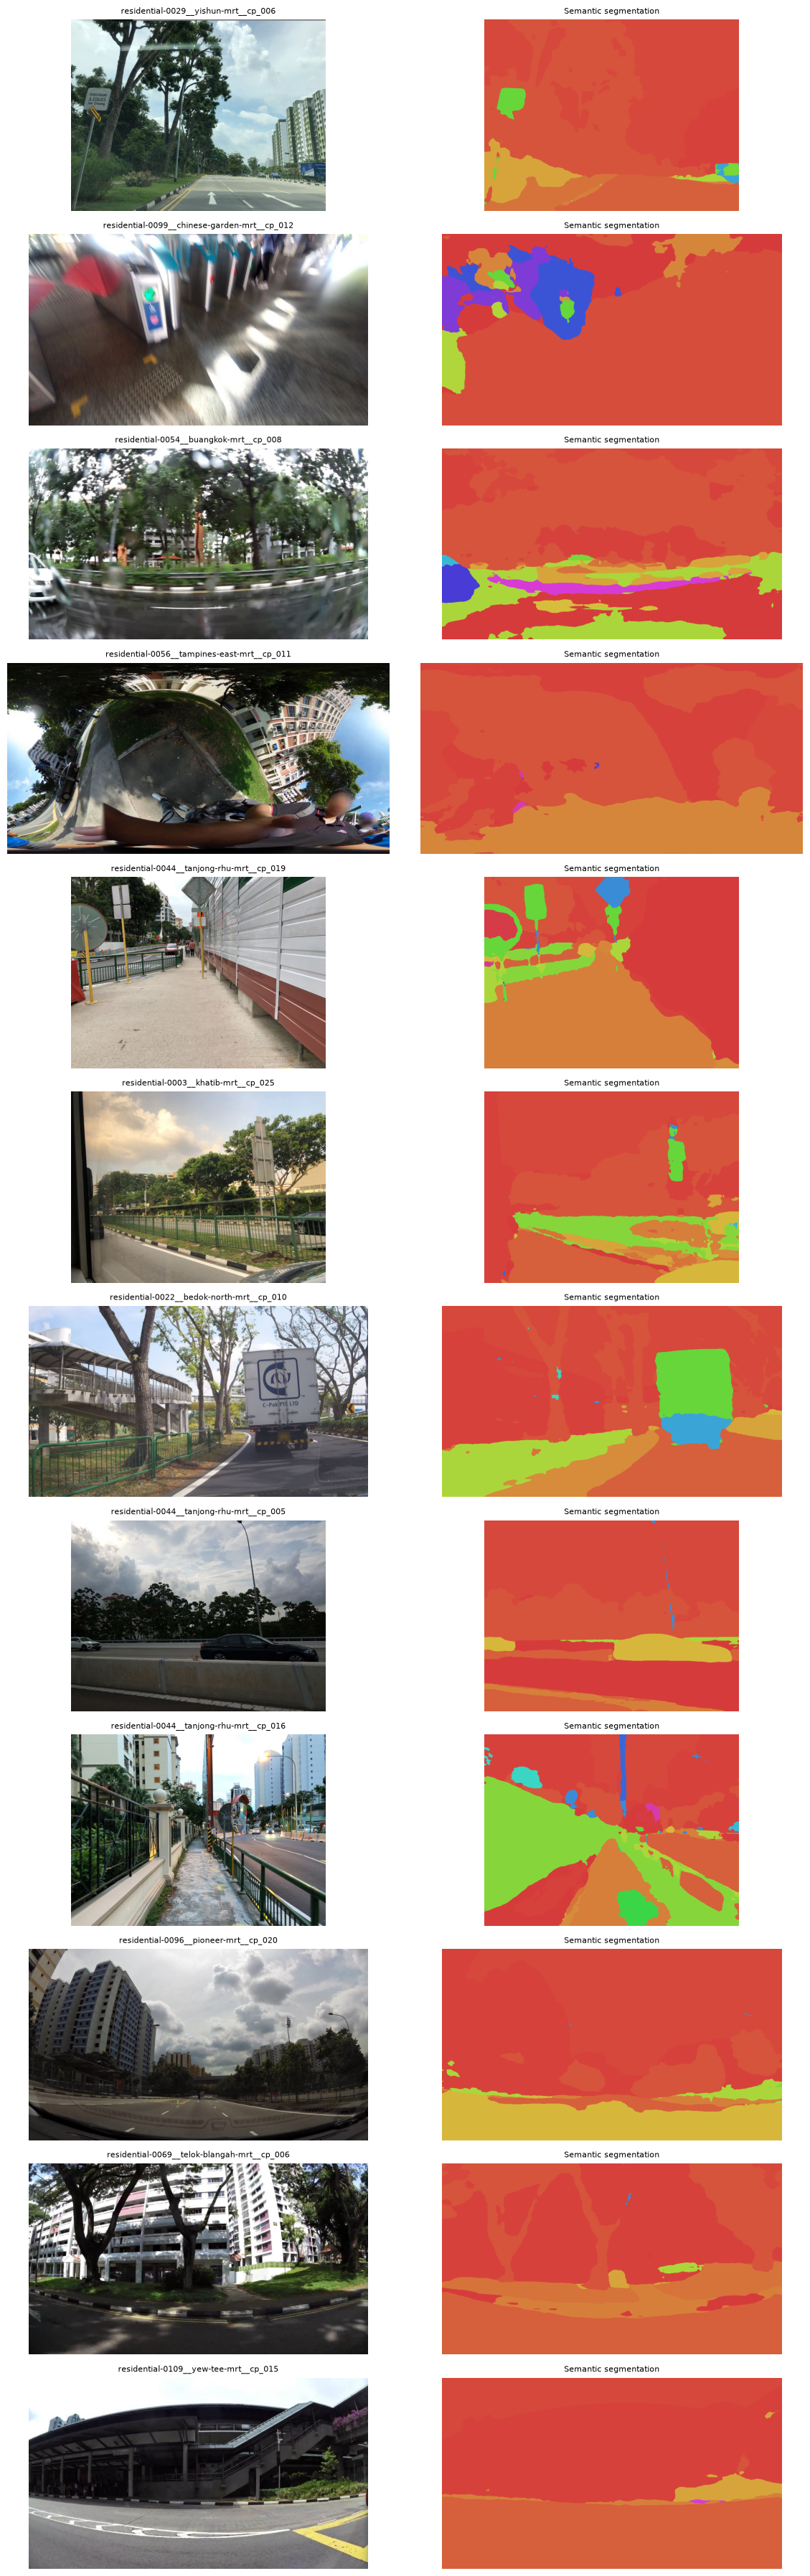

In [11]:
# ============================================================
# CELL 11 — SEGMENTATION MONTAGE
# ============================================================

sample_count = min(
    12,
    len(
        analysis_df
    )
)


samples = (
    analysis_df
    .sample(
        n=sample_count,
        random_state=RANDOM_STATE
    )
)


fig, axes = plt.subplots(
    sample_count,
    2,
    figsize=(
        12,
        sample_count * 3
    )
)


if sample_count == 1:

    axes = np.array([
        axes
    ])


for row_number, (
    _,
    row
) in enumerate(
    samples.iterrows()
):

    original_path = (
        PROJECT_DIR
        /
        row[
            "originalImage"
        ]
        .replace(
            "./",
            ""
        )
    )


    segmentation_path = (
        PROJECT_DIR
        /
        row[
            "segmentationImage"
        ]
        .replace(
            "./",
            ""
        )
    )


    if original_path.exists():

        axes[
            row_number,
            0
        ].imshow(
            Image.open(
                original_path
            )
        )


    if segmentation_path.exists():

        axes[
            row_number,
            1
        ].imshow(
            Image.open(
                segmentation_path
            )
        )


    axes[
        row_number,
        0
    ].set_title(
        row[
            "checkpointId"
        ],
        fontsize=8
    )


    axes[
        row_number,
        1
    ].set_title(
        "Semantic segmentation",
        fontsize=8
    )


    axes[
        row_number,
        0
    ].axis(
        "off"
    )


    axes[
        row_number,
        1
    ].axis(
        "off"
    )


plt.tight_layout()


SEGMENTATION_MONTAGE_PATH = (
    VISUAL_DIR
    /
    "segmentation_montage.png"
)


plt.savefig(
    SEGMENTATION_MONTAGE_PATH,
    dpi=180,
    bbox_inches="tight"
)


plt.show()

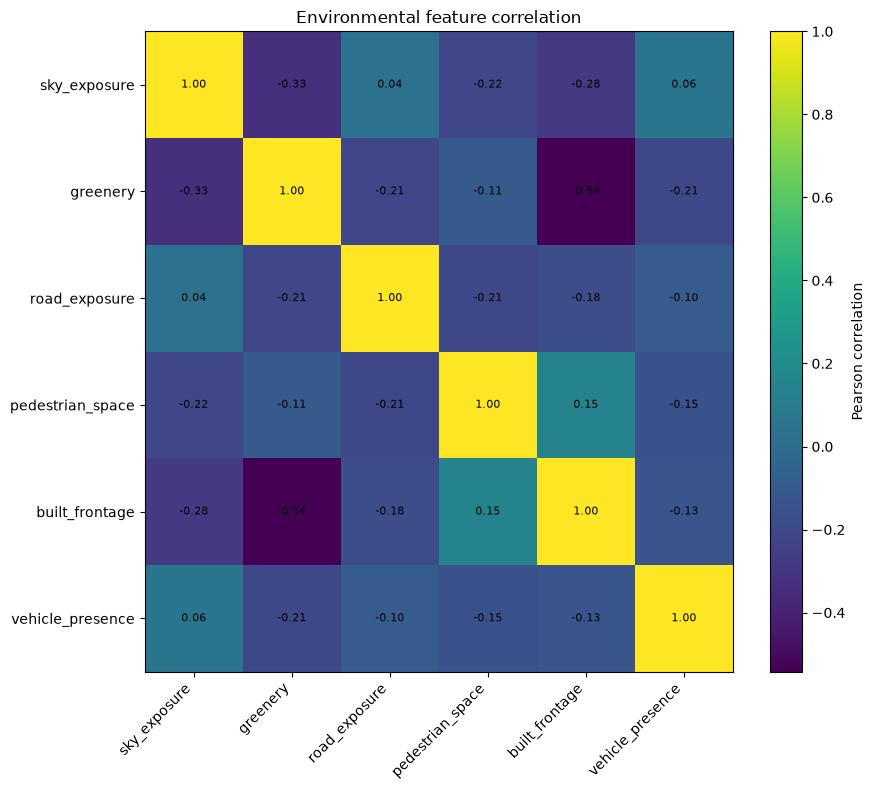

In [12]:
# ============================================================
# CELL 12 — FEATURE CORRELATION MATRIX
# ============================================================

correlation = (
    analysis_df[
        ENVIRONMENTAL_FEATURES
    ]
    .corr()
)


fig, ax = plt.subplots(
    figsize=(
        9,
        8
    )
)


matrix = (
    ax.imshow(
        correlation.to_numpy(),
        aspect="auto"
    )
)


ax.set_xticks(
    range(
        len(
            ENVIRONMENTAL_FEATURES
        )
    )
)


ax.set_yticks(
    range(
        len(
            ENVIRONMENTAL_FEATURES
        )
    )
)


ax.set_xticklabels(
    ENVIRONMENTAL_FEATURES,
    rotation=45,
    ha="right"
)


ax.set_yticklabels(
    ENVIRONMENTAL_FEATURES
)


for i in range(
    len(
        ENVIRONMENTAL_FEATURES
    )
):

    for j in range(
        len(
            ENVIRONMENTAL_FEATURES
        )
    ):

        ax.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )


fig.colorbar(
    matrix,
    ax=ax,
    label="Pearson correlation"
)


ax.set_title(
    "Environmental feature correlation"
)


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "feature_correlation_matrix.png",
    dpi=200
)


plt.show()

In [13]:
# ============================================================
# CELL 13 — STANDARDISE ML FEATURES
# ============================================================

X_environment = (
    analysis_df[
        ENVIRONMENTAL_FEATURES
    ]
    .to_numpy()
)


SCALER = (
    StandardScaler()
)


X_scaled = (
    SCALER.fit_transform(
        X_environment
    )
)


print(
    "ML matrix:",
    X_scaled.shape
)

ML matrix: (1985, 6)


In [14]:
# ============================================================
# CELL 14 — K-MEANS MODEL SELECTION
# ============================================================

k_results = []


for k in K_CANDIDATES:

    if (
        len(
            X_scaled
        )
        <=
        k
    ):

        continue


    model_test = (
        KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=30
        )
    )


    labels_test = (
        model_test.fit_predict(
            X_scaled
        )
    )


    k_results.append({

        "k":
            k,

        "inertia":
            float(
                model_test.inertia_
            ),

        "silhouette":
            float(
                silhouette_score(
                    X_scaled,
                    labels_test
                )
            )
    })


k_df = (
    pd.DataFrame(
        k_results
    )
)


display(
    k_df
)


BEST_K = int(

    k_df
    .sort_values(
        "silhouette",
        ascending=False
    )
    .iloc[0][
        "k"
    ]
)


print(
    "Selected K:",
    BEST_K
)

,k,inertia,silhouette
0,3,7990.049445,0.216640
1,4,6903.300741,0.238811
2,5,5823.240336,0.248389
3,6,4974.105982,0.244542


Selected K: 5


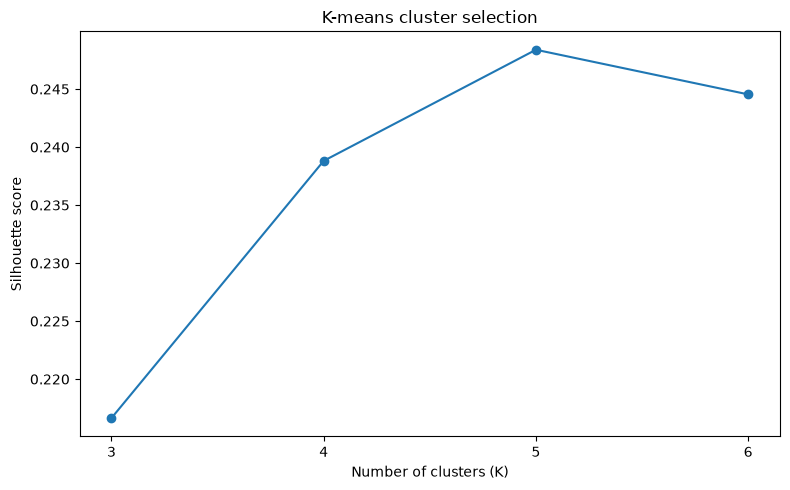

In [15]:
# ============================================================
# CELL 15 — K-MEANS DIAGNOSTIC GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        5
    )
)


ax.plot(
    k_df[
        "k"
    ],
    k_df[
        "silhouette"
    ],
    marker="o"
)


ax.set_xlabel(
    "Number of clusters (K)"
)

ax.set_ylabel(
    "Silhouette score"
)

ax.set_title(
    "K-means cluster selection"
)

ax.set_xticks(
    k_df[
        "k"
    ]
)


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "kmeans_silhouette_selection.png",
    dpi=200
)


plt.show()

In [16]:
# ============================================================
# CELL 16 — FINAL K-MEANS
# ============================================================

KMEANS = (
    KMeans(
        n_clusters=BEST_K,
        random_state=RANDOM_STATE,
        n_init=50
    )
)


analysis_df[
    "environmentCluster"
] = (
    KMEANS.fit_predict(
        X_scaled
    )
)


cluster_counts = (
    analysis_df[
        "environmentCluster"
    ]
    .value_counts()
    .sort_index()
)


print(
    cluster_counts
)

environmentCluster
0    450
1    626
2    160
3    733
4     16
Name: count, dtype: int64


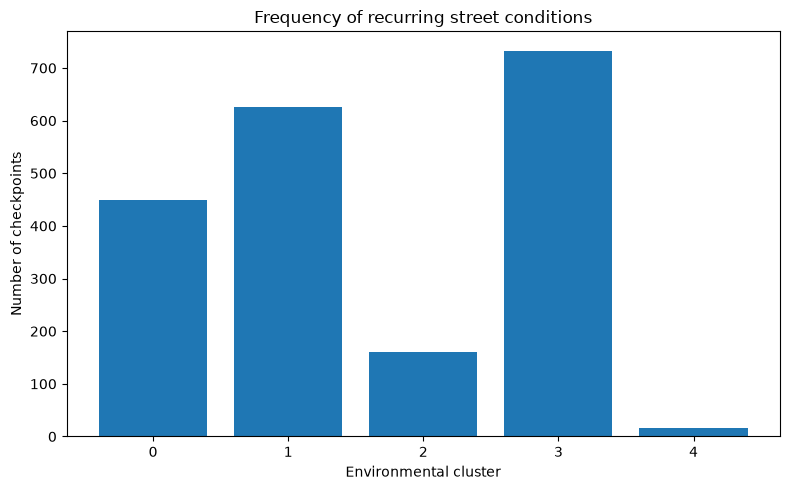

In [17]:
# ============================================================
# CELL 17 — CLUSTER SIZE GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        5
    )
)


ax.bar(
    cluster_counts.index.astype(
        str
    ),
    cluster_counts.values
)


ax.set_xlabel(
    "Environmental cluster"
)

ax.set_ylabel(
    "Number of checkpoints"
)

ax.set_title(
    "Frequency of recurring street conditions"
)


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "cluster_frequency.png",
    dpi=200
)


plt.show()

,sky_exposure,greenery,road_exposure,pedestrian_space,built_frontage,vehicle_presence
environmentCluster,,,,,,
0,0.089740,0.173228,0.141385,0.040980,0.448439,0.030526
1,0.325841,0.199384,0.183484,0.024076,0.158255,0.062030
2,0.093007,0.312188,0.060167,0.204966,0.233607,0.015152
3,0.117316,0.517358,0.160754,0.021440,0.109666,0.028005
4,0.021844,0.065689,0.095538,0.002897,0.015596,0.796396


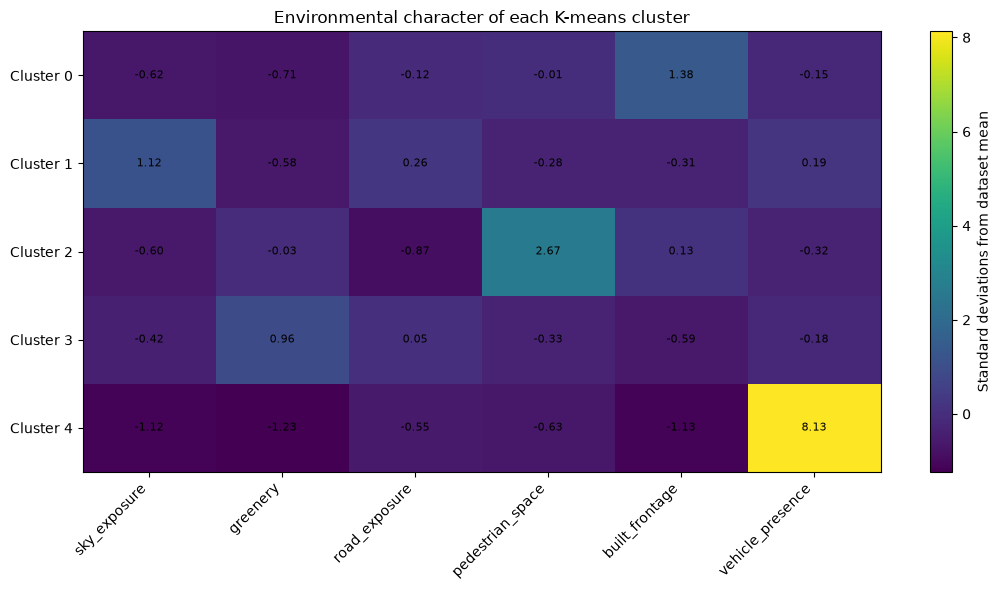

In [18]:
# ============================================================
# CELL 18 — CLUSTER PROFILE
# ============================================================

cluster_profile = (

    analysis_df
    .groupby(
        "environmentCluster"
    )[
        ENVIRONMENTAL_FEATURES
    ]
    .mean()
)


display(
    cluster_profile
)


global_mean = (
    analysis_df[
        ENVIRONMENTAL_FEATURES
    ]
    .mean()
)


global_std = (
    analysis_df[
        ENVIRONMENTAL_FEATURES
    ]
    .std()
    .replace(
        0,
        1
    )
)


cluster_profile_z = (
    (
        cluster_profile
        -
        global_mean
    )
    /
    global_std
)


fig, ax = plt.subplots(
    figsize=(
        11,
        6
    )
)


im = (
    ax.imshow(
        cluster_profile_z.to_numpy(),
        aspect="auto"
    )
)


ax.set_xticks(
    range(
        len(
            ENVIRONMENTAL_FEATURES
        )
    )
)


ax.set_xticklabels(
    ENVIRONMENTAL_FEATURES,
    rotation=45,
    ha="right"
)


ax.set_yticks(
    range(
        len(
            cluster_profile_z
        )
    )
)


ax.set_yticklabels(
    [
        f"Cluster {index}"
        for index in
        cluster_profile_z.index
    ]
)


for row in range(
    len(
        cluster_profile_z
    )
):

    for column in range(
        len(
            ENVIRONMENTAL_FEATURES
        )
    ):

        ax.text(
            column,
            row,
            f"{cluster_profile_z.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )


fig.colorbar(
    im,
    ax=ax,
    label="Standard deviations from dataset mean"
)


ax.set_title(
    "Environmental character of each K-means cluster"
)


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "cluster_environment_heatmap.png",
    dpi=200
)


plt.show()

In [19]:
# ============================================================
# CELL 19 — CLUSTER DESCRIPTIONS
# ============================================================

cluster_descriptions = {}


for cluster_id, row in (
    cluster_profile_z.iterrows()
):

    ordered = (
        row.sort_values(
            ascending=False
        )
    )


    strongest_positive = (
        ordered
        .head(
            2
        )
        .index
        .tolist()
    )


    strongest_negative = (
        ordered
        .tail(
            1
        )
        .index[
            0
        ]
    )


    description = (
        "High "
        +
        strongest_positive[0]
        .replace(
            "_",
            " "
        )
        +
        " + high "
        +
        strongest_positive[1]
        .replace(
            "_",
            " "
        )
        +
        " / low "
        +
        strongest_negative
        .replace(
            "_",
            " "
        )
    )


    cluster_descriptions[
        int(
            cluster_id
        )
    ] = (
        description
    )


analysis_df[
    "environmentTypology"
] = (
    analysis_df[
        "environmentCluster"
    ]
    .map(
        cluster_descriptions
    )
)


for cluster_id, description in (
    cluster_descriptions.items()
):

    print(
        f"Cluster {cluster_id}:",
        description
    )

Cluster 0: High built frontage + high pedestrian space / low greenery
Cluster 1: High sky exposure + high road exposure / low greenery
Cluster 2: High pedestrian space + high built frontage / low road exposure
Cluster 3: High greenery + high road exposure / low built frontage
Cluster 4: High vehicle presence + high road exposure / low greenery


In [20]:
# ============================================================
# CELL 20 — PCA
# ============================================================

PCA_MODEL = (
    PCA(
        n_components=2,
        random_state=RANDOM_STATE
    )
)


X_pca = (
    PCA_MODEL.fit_transform(
        X_scaled
    )
)


analysis_df[
    "pca1"
] = (
    X_pca[
        :,
        0
    ]
)


analysis_df[
    "pca2"
] = (
    X_pca[
        :,
        1
    ]
)


PCA_LOADINGS = (
    pd.DataFrame(

        PCA_MODEL.components_.T,

        index=
            ENVIRONMENTAL_FEATURES,

        columns=[
            "PC1",
            "PC2"
        ]
    )
)


PCA_LOADINGS.to_csv(
    PCA_LOADINGS_PATH
)


print(
    "Explained variance:"
)

print(
    PCA_MODEL.explained_variance_ratio_
)


display(
    PCA_LOADINGS
)

Explained variance:
[0.26862084 0.25355143]


,PC1,PC2
sky_exposure,-0.235483,-0.547590
greenery,-0.475214,0.625391
road_exposure,-0.187260,-0.334009
pedestrian_space,0.421133,0.303995
built_frontage,0.705774,-0.072129
vehicle_presence,-0.090458,-0.315997


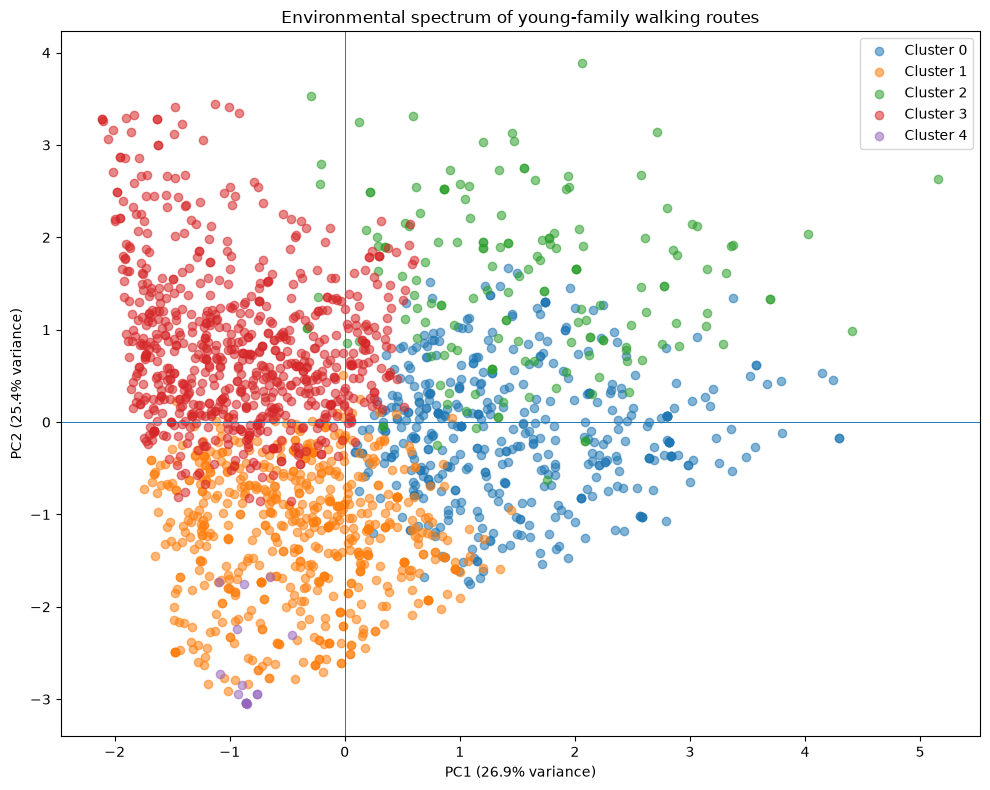

In [21]:
# ============================================================
# CELL 21 — PCA ENVIRONMENTAL SPECTRUM
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        10,
        8
    )
)


for cluster_id in sorted(
    analysis_df[
        "environmentCluster"
    ].unique()
):

    subset = (
        analysis_df[
            analysis_df[
                "environmentCluster"
            ]
            ==
            cluster_id
        ]
    )


    ax.scatter(
        subset[
            "pca1"
        ],
        subset[
            "pca2"
        ],
        alpha=0.55,
        label=
            f"Cluster {cluster_id}"
    )


ax.axhline(
    0,
    linewidth=0.7
)

ax.axvline(
    0,
    linewidth=0.7
)


ax.set_xlabel(
    f"PC1 ({PCA_MODEL.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

ax.set_ylabel(
    f"PC2 ({PCA_MODEL.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

ax.set_title(
    "Environmental spectrum of young-family walking routes"
)

ax.legend()


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "pca_environmental_spectrum.png",
    dpi=220
)


plt.show()

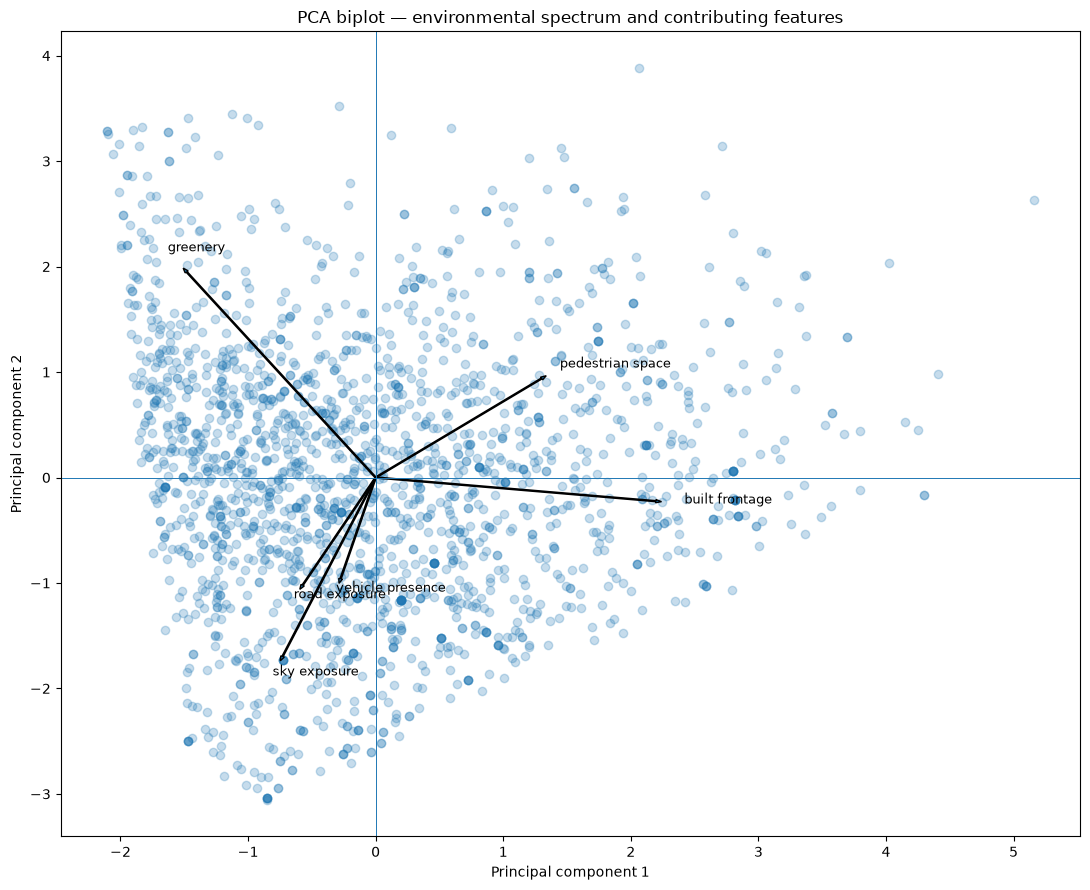

In [22]:
# ============================================================
# CELL 22 — PCA BIPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        11,
        9
    )
)


ax.scatter(
    analysis_df[
        "pca1"
    ],
    analysis_df[
        "pca2"
    ],
    alpha=0.25
)


scale = (
    max(
        analysis_df[
            "pca1"
        ].std(),
        analysis_df[
            "pca2"
        ].std()
    )
    *
    2.5
)


for feature in (
    ENVIRONMENTAL_FEATURES
):

    x = (
        PCA_LOADINGS.loc[
            feature,
            "PC1"
        ]
        *
        scale
    )

    y = (
        PCA_LOADINGS.loc[
            feature,
            "PC2"
        ]
        *
        scale
    )


    ax.arrow(
        0,
        0,
        x,
        y,
        width=0.01,
        length_includes_head=True
    )


    ax.text(
        x * 1.08,
        y * 1.08,
        feature.replace(
            "_",
            " "
        ),
        fontsize=9
    )


ax.axhline(
    0,
    linewidth=0.7
)

ax.axvline(
    0,
    linewidth=0.7
)


ax.set_title(
    "PCA biplot — environmental spectrum and contributing features"
)

ax.set_xlabel(
    "Principal component 1"
)

ax.set_ylabel(
    "Principal component 2"
)


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "pca_biplot.png",
    dpi=220
)


plt.show()

In [23]:
# ============================================================
# CELL 23 — HIERARCHICAL CLUSTERING
# ============================================================

AGGLOMERATIVE = (
    AgglomerativeClustering(
        n_clusters=BEST_K,
        linkage="ward"
    )
)


analysis_df[
    "hierarchicalCluster"
] = (
    AGGLOMERATIVE.fit_predict(
        X_scaled
    )
)


cluster_agreement = (
    adjusted_rand_score(

        analysis_df[
            "environmentCluster"
        ],

        analysis_df[
            "hierarchicalCluster"
        ]
    )
)


print(
    "K-means ↔ hierarchical clustering"
)

print(
    "Adjusted Rand Index:",
    round(
        cluster_agreement,
        3
    )
)

K-means ↔ hierarchical clustering
Adjusted Rand Index: 0.28


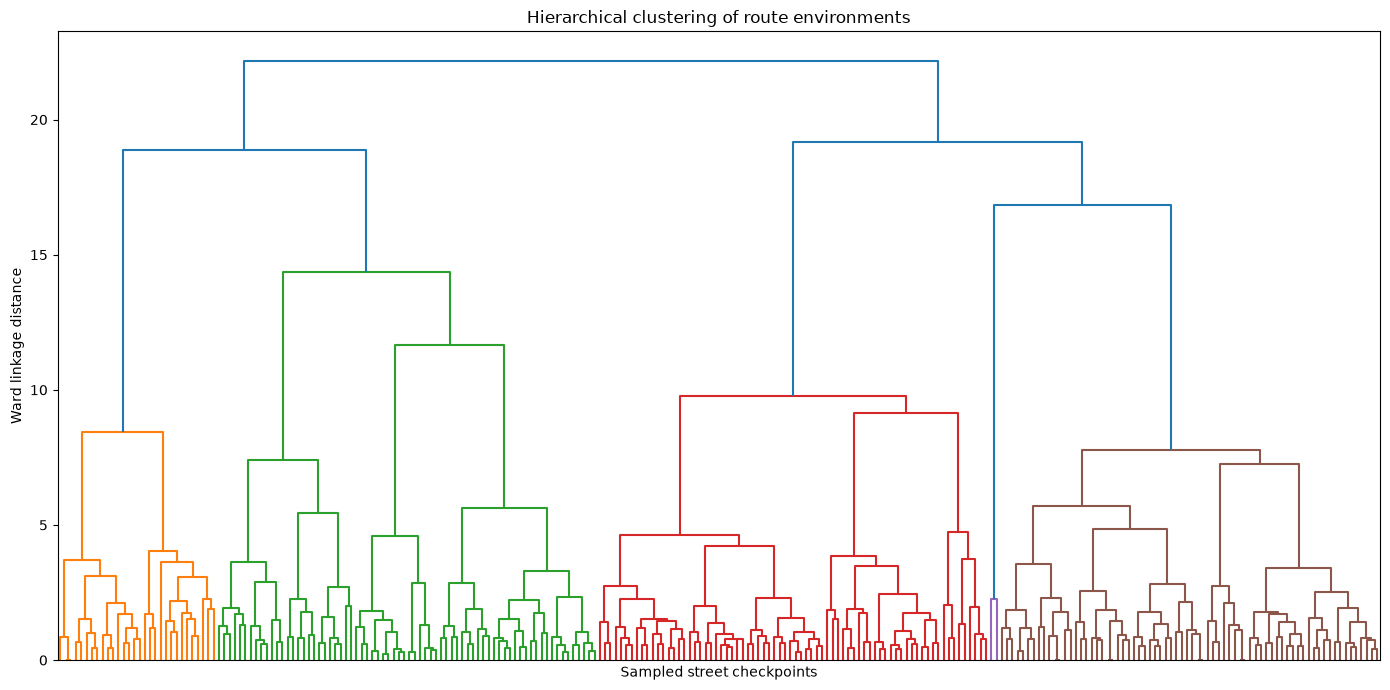

In [24]:
# ============================================================
# CELL 24 — HIERARCHICAL DENDROGRAM
# ============================================================

max_dendrogram_samples = min(
    250,
    len(
        X_scaled
    )
)


rng = (
    np.random.default_rng(
        RANDOM_STATE
    )
)


sample_indices = (
    rng.choice(
        len(
            X_scaled
        ),
        size=
            max_dendrogram_samples,
        replace=False
    )
)


sample_matrix = (
    X_scaled[
        sample_indices
    ]
)


linkage_matrix = (
    linkage(
        sample_matrix,
        method="ward"
    )
)


fig, ax = plt.subplots(
    figsize=(
        14,
        7
    )
)


dendrogram(
    linkage_matrix,
    no_labels=True,
    ax=ax
)


ax.set_title(
    "Hierarchical clustering of route environments"
)

ax.set_xlabel(
    "Sampled street checkpoints"
)

ax.set_ylabel(
    "Ward linkage distance"
)


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "hierarchical_dendrogram.png",
    dpi=200
)


plt.show()

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

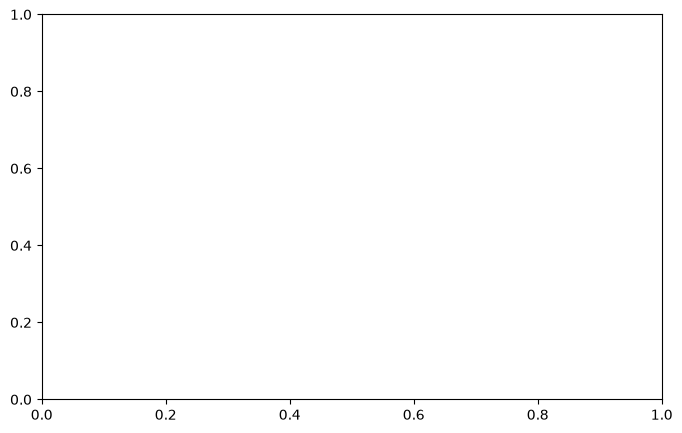

In [26]:
# ============================================================
# CELL 25 — FEATURE DISTRIBUTIONS
# ============================================================

for feature in (
    ENVIRONMENTAL_FEATURES
):

    cluster_values = [

        analysis_df.loc[
            analysis_df[
                "environmentCluster"
            ]
            ==
            cluster_id,
            feature
        ]
        .to_numpy()

        for cluster_id in sorted(
            analysis_df[
                "environmentCluster"
            ].unique()
        )
    ]


    fig, ax = plt.subplots(
        figsize=(
            8,
            5
        )
    )


    ax.boxplot(
        cluster_values,
        labels=[
            f"C{cluster_id}"
            for cluster_id in sorted(
                analysis_df[
                    "environmentCluster"
                ].unique()
            )
        ]
    )


    ax.set_title(
        feature.replace(
            "_",
            " "
        ).title()
        +
        " by environmental cluster"
    )


    ax.set_xlabel(
        "Cluster"
    )

    ax.set_ylabel(
        "Image proportion"
    )


    plt.tight_layout()


    plt.savefig(
        VISUAL_DIR
        /
        (
            "distribution_"
            +
            feature
            +
            ".png"
        ),
        dpi=180
    )


    plt.show()

In [27]:
# ============================================================
# CELL 26 — EXPLAINABLE DECISION TREE
# ============================================================

X_tree = (
    analysis_df[
        ENVIRONMENTAL_FEATURES
    ]
)


y_tree = (
    analysis_df[
        "environmentCluster"
    ]
)


(
    X_train,
    X_test,
    y_train,
    y_test
) = (
    train_test_split(
        X_tree,
        y_tree,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_tree
    )
)


CLUSTER_TREE = (
    DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=10,
        random_state=RANDOM_STATE
    )
)


CLUSTER_TREE.fit(
    X_train,
    y_train
)


tree_accuracy = (
    CLUSTER_TREE.score(
        X_test,
        y_test
    )
)


print(
    "Decision-tree surrogate accuracy:",
    round(
        tree_accuracy,
        3
    )
)


print()
print(
    export_text(
        CLUSTER_TREE,
        feature_names=
            ENVIRONMENTAL_FEATURES
    )
)

Decision-tree surrogate accuracy: 0.907

|--- greenery <= 0.34
|   |--- sky_exposure <= 0.24
|   |   |--- built_frontage <= 0.27
|   |   |   |--- sky_exposure <= 0.16
|   |   |   |   |--- class: 3
|   |   |   |--- sky_exposure >  0.16
|   |   |   |   |--- class: 1
|   |   |--- built_frontage >  0.27
|   |   |   |--- pedestrian_space <= 0.15
|   |   |   |   |--- class: 0
|   |   |   |--- pedestrian_space >  0.15
|   |   |   |   |--- class: 2
|   |--- sky_exposure >  0.24
|   |   |--- built_frontage <= 0.40
|   |   |   |--- pedestrian_space <= 0.11
|   |   |   |   |--- class: 1
|   |   |   |--- pedestrian_space >  0.11
|   |   |   |   |--- class: 2
|   |   |--- built_frontage >  0.40
|   |   |   |--- class: 0
|--- greenery >  0.34
|   |--- pedestrian_space <= 0.12
|   |   |--- sky_exposure <= 0.25
|   |   |   |--- built_frontage <= 0.32
|   |   |   |   |--- class: 3
|   |   |   |--- built_frontage >  0.32
|   |   |   |   |--- class: 0
|   |   |--- sky_exposure >  0.25
|   |   |   |--- gr

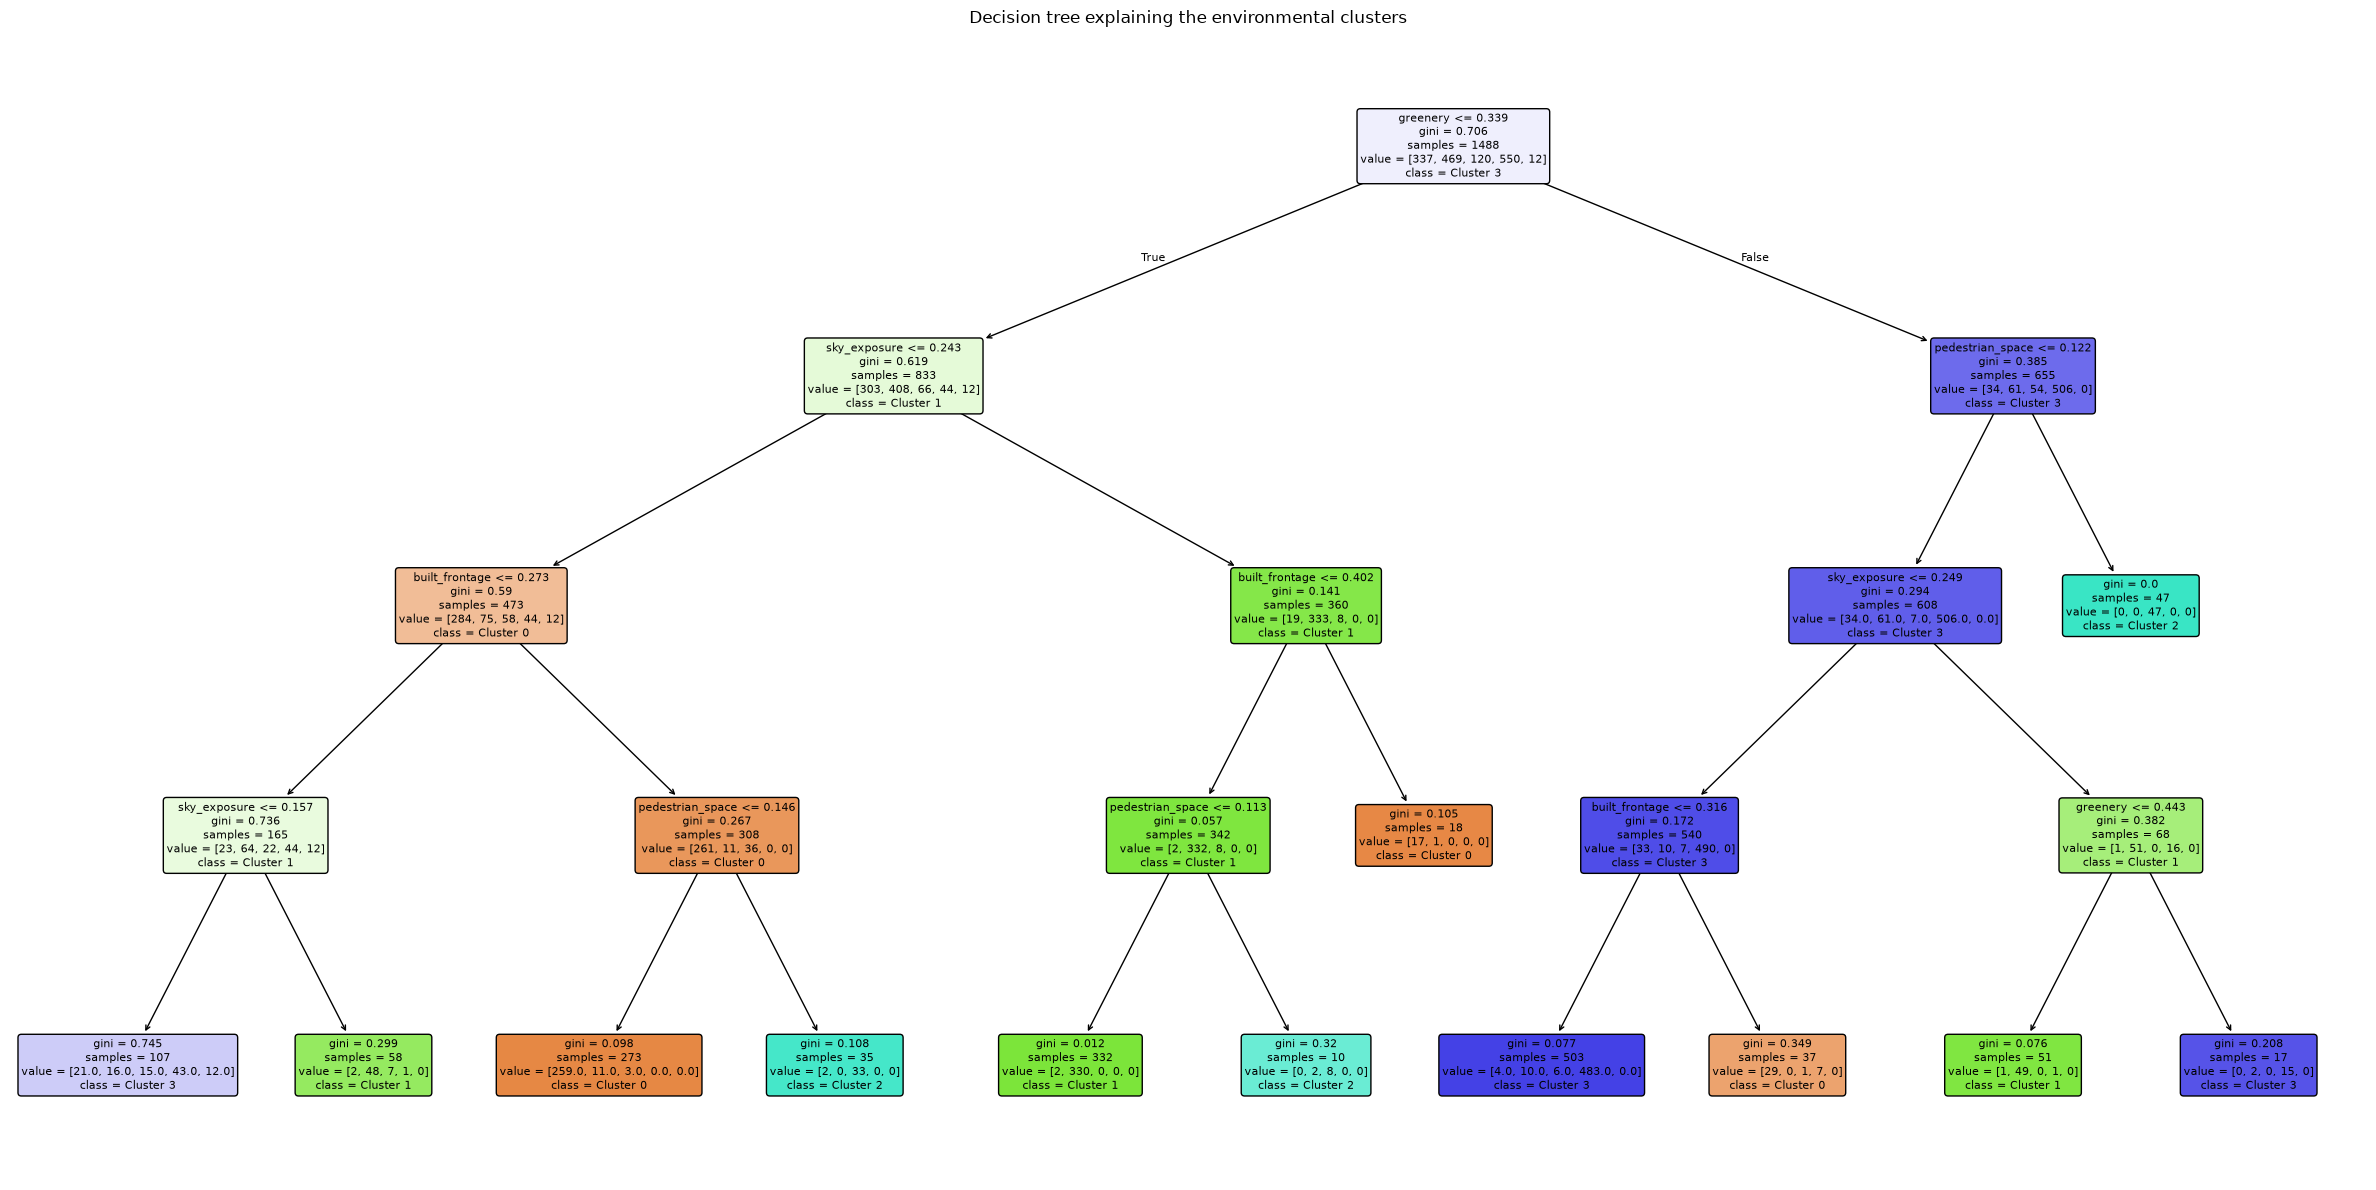

In [28]:
# ============================================================
# CELL 27 — DECISION TREE VISUAL
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        24,
        12
    )
)


plot_tree(
    CLUSTER_TREE,
    feature_names=
        ENVIRONMENTAL_FEATURES,
    class_names=[
        f"Cluster {cluster_id}"
        for cluster_id in
        CLUSTER_TREE.classes_
    ],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)


ax.set_title(
    "Decision tree explaining the environmental clusters"
)


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "environment_cluster_decision_tree.png",
    dpi=220,
    bbox_inches="tight"
)


plt.show()

greenery            0.353196
sky_exposure        0.315176
built_frontage      0.170885
pedestrian_space    0.160743
road_exposure       0.000000
vehicle_presence    0.000000
dtype: float64

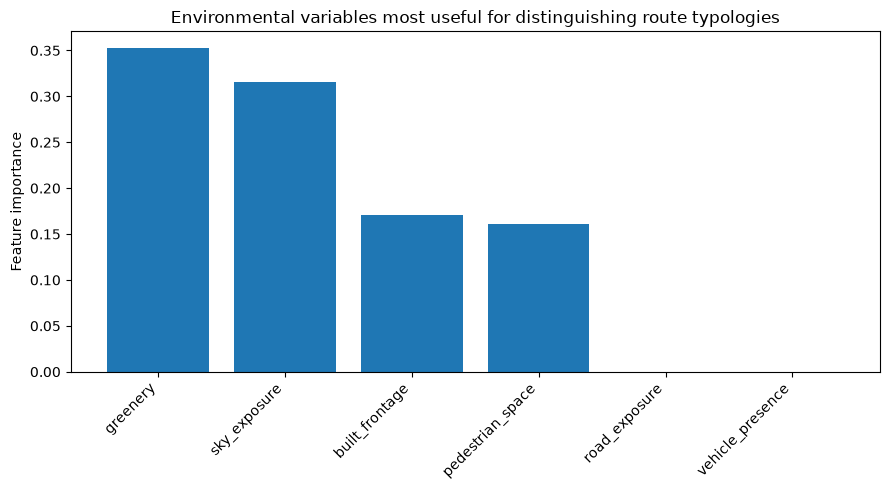

In [29]:
# ============================================================
# CELL 28 — DECISION TREE FEATURE IMPORTANCE
# ============================================================

feature_importance = (
    pd.Series(
        CLUSTER_TREE.feature_importances_,
        index=
            ENVIRONMENTAL_FEATURES
    )
    .sort_values(
        ascending=False
    )
)


display(
    feature_importance
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)


ax.bar(
    feature_importance.index,
    feature_importance.values
)


ax.set_xticklabels(
    feature_importance.index,
    rotation=45,
    ha="right"
)


ax.set_ylabel(
    "Feature importance"
)

ax.set_title(
    "Environmental variables most useful for distinguishing route typologies"
)


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "decision_tree_feature_importance.png",
    dpi=200
)


plt.show()

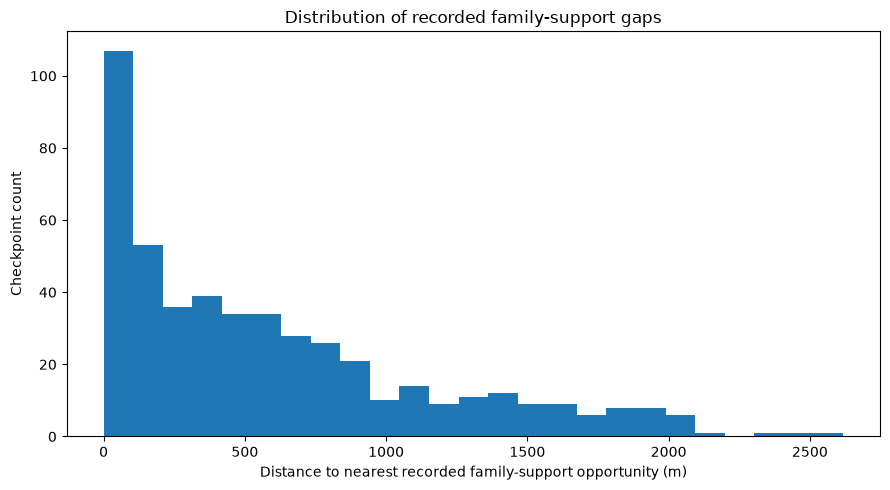

In [30]:
# ============================================================
# CELL 29 — RECORDED-SUPPORT GAP DISTRIBUTION
# ============================================================

gap_values = (
    analysis_df[
        "distanceToNearestRecordedSupportM"
    ]
    .dropna()
)


if len(
    gap_values
):

    fig, ax = plt.subplots(
        figsize=(
            9,
            5
        )
    )


    ax.hist(
        gap_values,
        bins=25
    )


    ax.set_xlabel(
        "Distance to nearest recorded family-support opportunity (m)"
    )

    ax.set_ylabel(
        "Checkpoint count"
    )

    ax.set_title(
        "Distribution of recorded family-support gaps"
    )


    plt.tight_layout()


    plt.savefig(
        VISUAL_DIR
        /
        "support_gap_distribution.png",
        dpi=200
    )


    plt.show()


else:

    print(
        "No routes with recorded support available for gap histogram."
    )

recordedSupport,False,True
environmentCluster,,
0,443,7
1,607,19
2,150,10
3,707,26
4,16,0


recordedSupport,False,True
environmentCluster,,
0,98.444444,1.555556
1,96.964856,3.035144
2,93.750000,6.250000
3,96.452933,3.547067
4,100.000000,0.000000


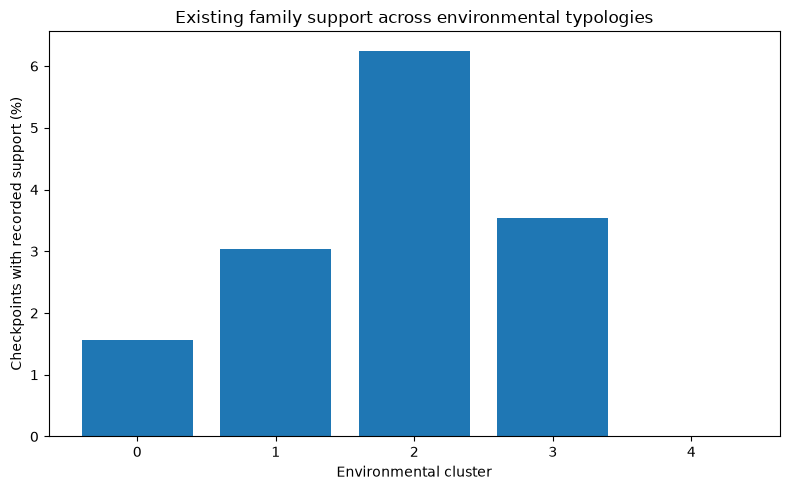

In [31]:
# ============================================================
# CELL 30 — CLUSTER × RECORDED SUPPORT
# ============================================================

cluster_support_table = (
    pd.crosstab(

        analysis_df[
            "environmentCluster"
        ],

        analysis_df[
            "recordedSupport"
        ]
    )
)


display(
    cluster_support_table
)


cluster_support_percent = (
    pd.crosstab(

        analysis_df[
            "environmentCluster"
        ],

        analysis_df[
            "recordedSupport"
        ],

        normalize="index"
    )
    *
    100
)


display(
    cluster_support_percent
)


fig, ax = plt.subplots(
    figsize=(
        8,
        5
    )
)


if True in (
    cluster_support_percent.columns
):

    values = (
        cluster_support_percent[
            True
        ]
    )


else:

    values = (
        pd.Series(
            0,
            index=
                cluster_support_percent.index
        )
    )


ax.bar(
    values.index.astype(
        str
    ),
    values.values
)


ax.set_xlabel(
    "Environmental cluster"
)

ax.set_ylabel(
    "Checkpoints with recorded support (%)"
)

ax.set_title(
    "Existing family support across environmental typologies"
)


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "cluster_support_availability.png",
    dpi=200
)


plt.show()

In [32]:
# ============================================================
# CELL 31 — ROUTE ENVIRONMENT PROFILES
# ============================================================

route_profiles = {}


for route_id, group in (
    analysis_df.groupby(
        "routeId"
    )
):

    ordered = (
        group.sort_values(
            "distanceFromOriginM"
        )
    )


    route_profiles[
        route_id
    ] = {

        "distanceM":
            ordered[
                "distanceFromOriginM"
            ]
            .tolist(),

        "skyExposure":
            ordered[
                "sky_exposure"
            ]
            .tolist(),

        "greenery":
            ordered[
                "greenery"
            ]
            .tolist(),

        "roadExposure":
            ordered[
                "road_exposure"
            ]
            .tolist(),

        "pedestrianSpace":
            ordered[
                "pedestrian_space"
            ]
            .tolist(),

        "environmentCluster":
            ordered[
                "environmentCluster"
            ]
            .astype(
                int
            )
            .tolist(),

        "recordedSupport":
            ordered[
                "recordedSupport"
            ]
            .astype(
                bool
            )
            .tolist()
    }


print(
    "Route profiles:",
    len(
        route_profiles
    )
)

Route profiles: 120


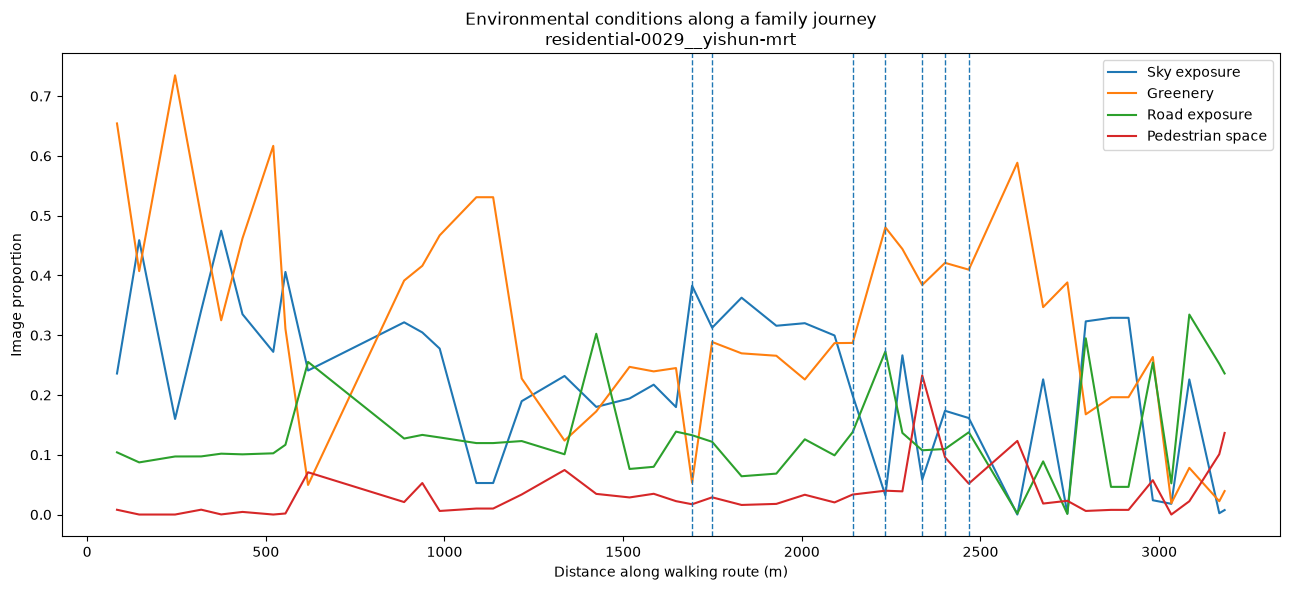

In [33]:
# ============================================================
# CELL 32 — EXAMPLE ROUTE PROFILE
# ============================================================

example_route_id = (
    analysis_df[
        "routeId"
    ]
    .value_counts()
    .index[
        0
    ]
)


example = (
    analysis_df[
        analysis_df[
            "routeId"
        ]
        ==
        example_route_id
    ]
    .sort_values(
        "distanceFromOriginM"
    )
)


fig, ax = plt.subplots(
    figsize=(
        13,
        6
    )
)


ax.plot(
    example[
        "distanceFromOriginM"
    ],
    example[
        "sky_exposure"
    ],
    label="Sky exposure"
)


ax.plot(
    example[
        "distanceFromOriginM"
    ],
    example[
        "greenery"
    ],
    label="Greenery"
)


ax.plot(
    example[
        "distanceFromOriginM"
    ],
    example[
        "road_exposure"
    ],
    label="Road exposure"
)


ax.plot(
    example[
        "distanceFromOriginM"
    ],
    example[
        "pedestrian_space"
    ],
    label="Pedestrian space"
)


support_rows = (
    example[
        example[
            "recordedSupport"
        ]
        ==
        True
    ]
)


for distance in (
    support_rows[
        "distanceFromOriginM"
    ]
):

    ax.axvline(
        distance,
        linestyle="--",
        linewidth=1
    )


ax.set_xlabel(
    "Distance along walking route (m)"
)

ax.set_ylabel(
    "Image proportion"
)

ax.set_title(
    "Environmental conditions along a family journey\n"
    +
    example_route_id
)

ax.legend()


plt.tight_layout()


plt.savefig(
    VISUAL_DIR
    /
    "example_route_environment_profile.png",
    dpi=220
)


plt.show()

In [34]:
# ============================================================
# CELL 33 — HUMAN LABEL TEMPLATE
# ============================================================

SUPERVISED_INPUT_FEATURES = [

    *ENVIRONMENTAL_FEATURES,

    "distanceToNearestRecordedSupportM",

    "routeNearParkConnector",

    "recordedSupport"
]


if not TRAINING_LABEL_PATH.exists():

    label_template = (

        analysis_df[
            [
                "checkpointId",
                "routeId",
                "originalImage",
                "segmentationImage",
                "environmentCluster",
                "environmentTypology",
                *SUPERVISED_INPUT_FEATURES
            ]
        ]
        .copy()
    )


    label_template[
        "supportNeedLabel"
    ] = ""


    label_template.to_csv(
        TRAINING_LABEL_PATH,
        index=False
    )


    print(
        "Created:"
    )

    print(
        TRAINING_LABEL_PATH
    )

    print()

    print(
        "Later label selected examples with:"
    )

    print(
        "low / medium / high"
    )


else:

    print(
        "Label template already exists:"
    )

    print(
        TRAINING_LABEL_PATH
    )

Created:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\ml_analysis\support_need_training_labels.csv

Later label selected examples with:
low / medium / high


In [35]:
# ============================================================
# CELL 34 — OPTIONAL SUPPORT-NEED CLASSIFIER
# ============================================================

SUPPORT_NEED_MODEL = None

SUPPORT_MODEL_REPORT = None


labels_df = (
    pd.read_csv(
        TRAINING_LABEL_PATH
    )
)


labels_df[
    "supportNeedLabel"
] = (
    labels_df[
        "supportNeedLabel"
    ]
    .fillna(
        ""
    )
    .astype(
        str
    )
    .str.strip()
    .str.lower()
)


labelled_df = (
    labels_df[
        labels_df[
            "supportNeedLabel"
        ]
        .isin([
            "low",
            "medium",
            "high"
        ])
    ]
    .copy()
)


print(
    "Human-labelled checkpoints:",
    len(
        labelled_df
    )
)


if (
    len(
        labelled_df
    )
    >=
    30
    and
    labelled_df[
        "supportNeedLabel"
    ]
    .nunique()
    >=
    2
):

    model_features = (
        SUPERVISED_INPUT_FEATURES
    )


    training_data = (
        labelled_df[
            model_features
        ]
        .copy()
    )


    # Missing support distance can mean no mapped support
    # on the selected route. Keep it as a separate large
    # contextual value rather than silently calling it zero.

    max_route_distance = (
        analysis_df[
            "routeDistanceM"
        ]
        .max()
    )


    training_data[
        "distanceToNearestRecordedSupportM"
    ] = (
        training_data[
            "distanceToNearestRecordedSupportM"
        ]
        .fillna(
            max_route_distance
        )
    )


    for column in [
        "routeNearParkConnector",
        "recordedSupport"
    ]:

        training_data[
            column
        ] = (
            training_data[
                column
            ]
            .astype(
                int
            )
        )


    y = (
        labelled_df[
            "supportNeedLabel"
        ]
    )


    (
        X_train,
        X_test,
        y_train,
        y_test
    ) = (
        train_test_split(
            training_data,
            y,
            test_size=0.25,
            random_state=RANDOM_STATE,
            stratify=y
        )
    )


    SUPPORT_NEED_MODEL = (
        DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )


    SUPPORT_NEED_MODEL.fit(
        X_train,
        y_train
    )


    predictions = (
        SUPPORT_NEED_MODEL.predict(
            X_test
        )
    )


    SUPPORT_MODEL_REPORT = (
        classification_report(
            y_test,
            predictions,
            output_dict=True,
            zero_division=0
        )
    )


    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )


    # ========================================================
    # APPLY TO FULL DATASET
    # ========================================================

    full_input = (
        analysis_df[
            model_features
        ]
        .copy()
    )


    full_input[
        "distanceToNearestRecordedSupportM"
    ] = (
        full_input[
            "distanceToNearestRecordedSupportM"
        ]
        .fillna(
            max_route_distance
        )
    )


    for column in [
        "routeNearParkConnector",
        "recordedSupport"
    ]:

        full_input[
            column
        ] = (
            full_input[
                column
            ]
            .astype(
                int
            )
        )


    probabilities = (
        SUPPORT_NEED_MODEL.predict_proba(
            full_input
        )
    )


    analysis_df[
        "supportNeed"
    ] = (
        SUPPORT_NEED_MODEL.predict(
            full_input
        )
    )


    analysis_df[
        "supportNeedConfidence"
    ] = (
        probabilities.max(
            axis=1
        )
    )


else:

    analysis_df[
        "supportNeed"
    ] = (
        "not_yet_labelled"
    )


    analysis_df[
        "supportNeedConfidence"
    ] = np.nan


    print()
    print(
        "Support-need Decision Tree skipped."
    )

    print(
        "This is deliberate: we will not fabricate "
        "ground-truth support labels."
    )

Human-labelled checkpoints: 0

Support-need Decision Tree skipped.
This is deliberate: we will not fabricate ground-truth support labels.


In [36]:
# ============================================================
# CELL 35 — SAVE MASTER ANALYSIS TABLE
# ============================================================

analysis_df.to_csv(
    CHECKPOINT_DATA_PATH,
    index=False
)


print(
    "Saved:"
)

print(
    CHECKPOINT_DATA_PATH
)

Saved:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\ml_analysis\checkpoint_environmental_analysis.csv


In [37]:
# ============================================================
# CELL 36 — GRASSHOPPER EXPORT
# ============================================================

GRASSHOPPER_COLUMNS = [

    "routeId",
    "checkpointId",

    "lat",
    "lon",

    "distanceFromOriginM",
    "routeDistanceM",

    "sky_exposure",
    "greenery",
    "road_exposure",
    "pedestrian_space",
    "built_frontage",
    "vehicle_presence",
    "human_presence",

    "environmentCluster",
    "environmentTypology",

    "hierarchicalCluster",

    "pca1",
    "pca2",

    "recordedSupport",

    "distanceToNearestRecordedSupportM",

    "supportGapPercentile",

    "routeNearParkConnector",

    "supportNeed",
    "supportNeedConfidence"
]


grasshopper_df = (
    analysis_df[
        GRASSHOPPER_COLUMNS
    ]
    .copy()
)


grasshopper_df.to_csv(
    GRASSHOPPER_PATH,
    index=False
)


print(
    "Grasshopper CSV:"
)

print(
    GRASSHOPPER_PATH
)


display(
    grasshopper_df.head(
        10
    )
)

Grasshopper CSV:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\grasshopper_route_features.csv


,routeId,checkpointId,lat,lon,distanceFromOriginM,routeDistanceM,sky_exposure,greenery,road_exposure,pedestrian_space,...,environmentTypology,hierarchicalCluster,pca1,pca2,recordedSupport,distanceToNearestRecordedSupportM,supportGapPercentile,routeNearParkConnector,supportNeed,supportNeedConfidence
0,residential-0001__kranji-mrt,residential-0001__kranji-mrt__cp_006,1.420135,103.759421,479.61,2376.4,0.157522,0.566040,0.237086,0.000341,...,High greenery + high road exposure / low built...,2,-1.787863,0.596251,False,NaN,NaN,False,not_yet_labelled,NaN
1,residential-0001__kranji-mrt,residential-0001__kranji-mrt__cp_007,1.419535,103.759644,550.78,2376.4,0.111979,0.595420,0.243407,0.004350,...,High greenery + high road exposure / low built...,2,-1.693979,0.864897,False,NaN,NaN,False,not_yet_labelled,NaN
2,residential-0001__kranji-mrt,residential-0001__kranji-mrt__cp_008,1.419039,103.760019,619.91,2376.4,0.121014,0.565080,0.238615,0.000288,...,High greenery + high road exposure / low built...,2,-1.725470,0.734920,False,NaN,NaN,False,not_yet_labelled,NaN
3,residential-0001__kranji-mrt,residential-0001__kranji-mrt__cp_009,1.418390,103.760796,732.46,2376.4,0.331379,0.440852,0.137524,0.001570,...,High sky exposure + high road exposure / low g...,1,-1.686929,-0.408986,False,NaN,NaN,False,not_yet_labelled,NaN
4,residential-0001__kranji-mrt,residential-0001__kranji-mrt__cp_010,1.418103,103.761205,788.01,2376.4,0.281342,0.485982,0.139460,0.000000,...,High greenery + high road exposure / low built...,1,-1.667182,-0.118251,False,NaN,NaN,False,not_yet_labelled,NaN
5,residential-0001__kranji-mrt,residential-0001__kranji-mrt__cp_011,1.417616,103.761877,880.28,2376.4,0.128922,0.513814,0.231035,0.005022,...,High greenery + high road exposure / low built...,2,-1.542185,0.587446,False,NaN,NaN,False,not_yet_labelled,NaN
6,residential-0001__kranji-mrt,residential-0001__kranji-mrt__cp_012,1.417333,103.761677,918.80,2376.4,0.105077,0.594398,0.229090,0.000159,...,High greenery + high road exposure / low built...,2,-1.750860,0.913462,False,NaN,NaN,False,not_yet_labelled,NaN
7,residential-0001__kranji-mrt,residential-0001__kranji-mrt__cp_013,1.417746,103.761108,996.97,2376.4,0.128252,0.624425,0.240967,0.000064,...,High greenery + high road exposure / low built...,2,-1.881733,0.873501,False,NaN,NaN,False,not_yet_labelled,NaN
8,residential-0001__kranji-mrt,residential-0001__kranji-mrt__cp_014,1.418354,103.760664,1080.67,2376.4,0.331379,0.440852,0.137524,0.001570,...,High sky exposure + high road exposure / low g...,1,-1.686929,-0.408986,False,NaN,NaN,False,not_yet_labelled,NaN
9,residential-0001__kranji-mrt,residential-0001__kranji-mrt__cp_015,1.418995,103.759886,1192.74,2376.4,0.121014,0.565080,0.238615,0.000288,...,High greenery + high road exposure / low built...,2,-1.725470,0.734920,False,NaN,NaN,False,not_yet_labelled,NaN


In [38]:
# ============================================================
# CELL 37 — CLUSTER SUMMARY
# ============================================================

cluster_summary_json = {}


for cluster_id, row in (
    cluster_profile.iterrows()
):

    cluster_summary_json[
        str(
            int(
                cluster_id
            )
        )
    ] = {

        "description":
            cluster_descriptions[
                int(
                    cluster_id
                )
            ],

        "checkpointCount":
            int(
                (
                    analysis_df[
                        "environmentCluster"
                    ]
                    ==
                    cluster_id
                )
                .sum()
            ),

        "meanFeatures":
            {

                feature:
                    float(
                        row[
                            feature
                        ]
                    )

                for feature in
                ENVIRONMENTAL_FEATURES
            }
    }


with open(
    CLUSTER_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        cluster_summary_json,
        f,
        indent=2
    )


print(
    "Cluster summary saved."
)

Cluster summary saved.


In [39]:
# ============================================================
# CELL 38 — WEBSITE ANALYSIS JSON
# ============================================================

analysis_lookup = {

    row[
        "checkpointId"
    ]:
        row

    for _,
    row in
    analysis_df.iterrows()
}


final_routes = {}


for route_id, route in (
    ROUTES_BY_ID.items()
):

    route_copy = (
        json.loads(
            json.dumps(
                route
            )
        )
    )


    route_copy[
        "analysisReady"
    ] = True


    analysed_checkpoint_count = 0


    for checkpoint in (
        route_copy.get(
            "checkpoints",
            []
        )
    ):

        checkpoint_id = (
            checkpoint[
                "id"
            ]
        )


        if (
            checkpoint_id
            not in
            analysis_lookup
        ):

            continue


        row = (
            analysis_lookup[
                checkpoint_id
            ]
        )


        analysed_checkpoint_count += 1


        checkpoint[
            "environmentalFeatures"
        ] = {

            feature:
                float(
                    row[
                        feature
                    ]
                )

            for feature in
            ENVIRONMENTAL_FEATURES
        }


        checkpoint[
            "environmentCluster"
        ] = int(
            row[
                "environmentCluster"
            ]
        )


        checkpoint[
            "environmentTypology"
        ] = (
            row[
                "environmentTypology"
            ]
        )


        checkpoint[
            "hierarchicalCluster"
        ] = int(
            row[
                "hierarchicalCluster"
            ]
        )


        checkpoint[
            "pca"
        ] = {

            "x":
                float(
                    row[
                        "pca1"
                    ]
                ),

            "y":
                float(
                    row[
                        "pca2"
                    ]
                )
        }


        distance_support = (
            row[
                "distanceToNearestRecordedSupportM"
            ]
        )


        checkpoint[
            "distanceToNearestRecordedSupportM"
        ] = (

            None

            if pd.isna(
                distance_support
            )

            else float(
                distance_support
            )
        )


        gap_percentile = (
            row[
                "supportGapPercentile"
            ]
        )


        checkpoint[
            "supportGapPercentile"
        ] = (

            None

            if pd.isna(
                gap_percentile
            )

            else float(
                gap_percentile
            )
        )


        checkpoint[
            "supportNeed"
        ] = (
            row[
                "supportNeed"
            ]
        )


        confidence = (
            row[
                "supportNeedConfidence"
            ]
        )


        checkpoint[
            "supportNeedConfidence"
        ] = (

            None

            if pd.isna(
                confidence
            )

            else float(
                confidence
            )
        )


        checkpoint[
            "originalImage"
        ] = (
            row[
                "originalImage"
            ]
        )


        checkpoint[
            "segmentationImage"
        ] = (
            row[
                "segmentationImage"
            ]
        )


    route_copy[
        "analysedCheckpointCount"
    ] = (
        analysed_checkpoint_count
    )


    final_routes[
        route_id
    ] = (
        route_copy
    )


FINAL_OUTPUT = {

    "version":
        2,

    "generatedAt":
        datetime.now()
        .isoformat(),

    "pipeline": [

        "Mapillary street imagery",

        "SegFormer semantic segmentation",

        "Environmental feature extraction",

        "K-means clustering",

        "Hierarchical clustering validation",

        "PCA dimensionality reduction",

        "Decision-tree cluster interpretation",

        "Optional supervised support-need classification",

        "Grasshopper parameter export"
    ],

    "environmentalFeatures":
        ENVIRONMENTAL_FEATURES,

    "segmentationModel":
        MODEL_NAME,

    "kMeans": {

        "selectedK":
            BEST_K,

        "diagnostics":
            k_results
    },

    "hierarchicalClustering": {

        "clusterCount":
            BEST_K,

        "adjustedRandIndexAgainstKMeans":
            float(
                cluster_agreement
            )
    },

    "pca": {

        "explainedVarianceRatio":
            [
                float(
                    value
                )

                for value in
                PCA_MODEL.explained_variance_ratio_
            ],

        "loadings":
            {

                feature: {

                    "pc1":
                        float(
                            PCA_LOADINGS.loc[
                                feature,
                                "PC1"
                            ]
                        ),

                    "pc2":
                        float(
                            PCA_LOADINGS.loc[
                                feature,
                                "PC2"
                            ]
                        )
                }

                for feature in
                ENVIRONMENTAL_FEATURES
            }
    },

    "decisionTree": {

        "purpose":
            (
                "Explain K-means environmental typologies "
                "using human-readable feature thresholds."
            ),

        "surrogateAccuracy":
            float(
                tree_accuracy
            )
    },

    "supportNeedClassifier": {

        "trained":
            bool(
                SUPPORT_NEED_MODEL
                is not None
            ),

        "report":
            SUPPORT_MODEL_REPORT
    },

    "clusters":
        cluster_summary_json,

    "routeProfiles":
        route_profiles,

    "visualAssets": {

        "segmentationMontage":
            "./data/generated/ml_analysis/visuals/segmentation_montage.png",

        "featureCorrelation":
            "./data/generated/ml_analysis/visuals/feature_correlation_matrix.png",

        "kSelection":
            "./data/generated/ml_analysis/visuals/kmeans_silhouette_selection.png",

        "clusterHeatmap":
            "./data/generated/ml_analysis/visuals/cluster_environment_heatmap.png",

        "pcaSpectrum":
            "./data/generated/ml_analysis/visuals/pca_environmental_spectrum.png",

        "pcaBiplot":
            "./data/generated/ml_analysis/visuals/pca_biplot.png",

        "dendrogram":
            "./data/generated/ml_analysis/visuals/hierarchical_dendrogram.png",

        "decisionTree":
            "./data/generated/ml_analysis/visuals/environment_cluster_decision_tree.png",

        "featureImportance":
            "./data/generated/ml_analysis/visuals/decision_tree_feature_importance.png",

        "supportGapDistribution":
            "./data/generated/ml_analysis/visuals/support_gap_distribution.png",

        "exampleRouteProfile":
            "./data/generated/ml_analysis/visuals/example_route_environment_profile.png"
    },

    "routesById":
        final_routes,

    "routes":
        list(
            final_routes.values()
        )
}


with open(
    WEBSITE_ANALYSIS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        FINAL_OUTPUT,
        f,
        indent=2
    )


print(
    "Website analysis saved:"
)

print(
    WEBSITE_ANALYSIS_PATH
)

Website analysis saved:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\family_route_analysis.json


In [40]:
# ============================================================
# CELL 39 — FINAL SUMMARY
# ============================================================

print()
print(
    "============================================================"
)

print(
    "IMAGE + MACHINE LEARNING ANALYSIS COMPLETE"
)

print(
    "============================================================"
)

print(
    "Routes:",
    len(
        final_routes
    )
)

print(
    "Analysed checkpoints:",
    len(
        analysis_df
    )
)

print(
    "Environmental variables:",
    len(
        ENVIRONMENTAL_FEATURES
    )
)

print(
    "K-means clusters:",
    BEST_K
)

print(
    "K-means ↔ hierarchical ARI:",
    round(
        cluster_agreement,
        3
    )
)

print(
    "PCA explained variance:",
    [
        round(
            value,
            3
        )

        for value in
        PCA_MODEL.explained_variance_ratio_
    ]
)

print(
    "Decision-tree surrogate accuracy:",
    round(
        tree_accuracy,
        3
    )
)

print(
    "True support-need classifier trained:",
    SUPPORT_NEED_MODEL
    is not None
)

print()

print(
    "WEBSITE:"
)

print(
    WEBSITE_ANALYSIS_PATH
)

print()

print(
    "GRASSHOPPER:"
)

print(
    GRASSHOPPER_PATH
)

print()

print(
    "VISUALS:"
)

print(
    VISUAL_DIR
)

print(
    "============================================================"
)


IMAGE + MACHINE LEARNING ANALYSIS COMPLETE
Routes: 120
Analysed checkpoints: 1985
Environmental variables: 6
K-means clusters: 5
K-means ↔ hierarchical ARI: 0.28
PCA explained variance: [np.float64(0.269), np.float64(0.254)]
Decision-tree surrogate accuracy: 0.907
True support-need classifier trained: False

WEBSITE:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\family_route_analysis.json

GRASSHOPPER:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\grasshopper_route_features.csv

VISUALS:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\ml_analysis\visuals
